<a href="https://colab.research.google.com/github/hesha0/Swiggy-Financial-Data-Analysis-/blob/main/Copy_of_Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Financial Analysis & Portfolio Optimization
- **Components:** Data Pipeline, Time Series, Risk Metrics, Markowitz Optimization, and Text Analytics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')


plt.style.use('seaborn-v0_8-darkgrid')
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
start_date = '2023-01-01'
end_date = '2026-01-01'


data = yf.download(tickers, start=start_date, end=end_date)['Close']


print("--- Missing Values ---")
print(data.isnull().sum())

data = data.dropna()
print("\n--- Data Summary Statistics ---")
print(data.describe())

[*********************100%***********************]  5 of 5 completed


--- Missing Values ---
Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
TSLA     0
dtype: int64

--- Data Summary Statistics ---
Ticker        AAPL        AMZN       GOOGL        MSFT        TSLA
count   752.000000  752.000000  752.000000  752.000000  752.000000
mean    202.167913  174.584881  163.416670  393.108720  268.253285
std      34.308361   43.718781   49.609239   75.107982   88.567771
min     122.827621   83.120003   85.387489  215.750137  108.099998
25%     175.535622  135.480003  131.166855  329.609406  197.417500
50%     197.306412  182.070000  160.401443  404.706329  248.449997
75%     226.413078  213.615005  179.497078  439.384598  328.492493
max     285.413116  254.000000  322.601013  537.646362  489.880005


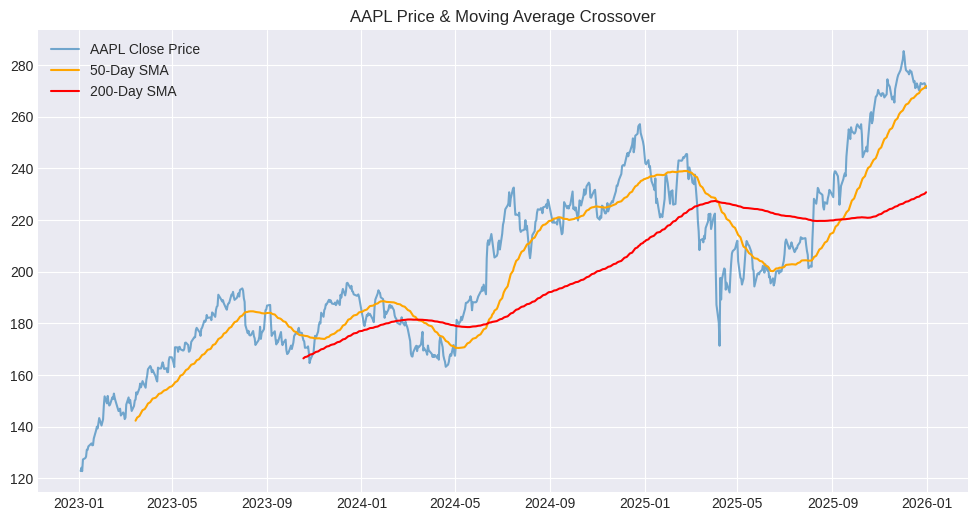

ADF Statistic: -1.40804145137154
p-value: 0.5784149315953346


In [ ]:

asset = 'AAPL'
df_ts = data[[asset]].dropna()

df_ts['SMA_50'] = df_ts[asset].rolling(window=50).mean()
df_ts['SMA_200'] = df_ts[asset].rolling(window=200).mean()


plt.figure(figsize=(12, 6))
plt.plot(df_ts.index, df_ts[asset], label=f'{asset} Close Price', alpha=0.6)
plt.plot(df_ts.index, df_ts['SMA_50'], label='50-Day SMA', color='orange')
plt.plot(df_ts.index, df_ts['SMA_200'], label='200-Day SMA', color='red')
plt.title(f'{asset} Price & Moving Average Crossover')
plt.legend()
plt.show()


adf_result = adfuller(df_ts[asset].dropna())
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

Time Series & Moving Average Interpretation

"Looking at the chart, the 50-day moving average crossing above the 200-day line signals a bullish momentum for the stock. Meanwhile, the ADF test results confirm that raw stock prices are non-stationary, which is why we rely on daily returns for modeling."

In [ ]:

returns = data.pct_change().dropna()


annualized_return = returns.mean() * 252
annualized_volatility = returns.std() * np.sqrt(252)
risk_free_rate = 0.04  # Assuming 4% risk-free rate
sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility


var_95 = np.percentile(returns, 5, axis=0)

risk_summary = pd.DataFrame({
    'Annualized Return': annualized_return,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio,
    'VaR (95%)': var_95
})
print(risk_summary)

        Annualized Return  Annualized Volatility  Sharpe Ratio  VaR (95%)
Ticker                                                                   
AAPL             0.298152               0.256012      1.008359  -0.024036
AMZN             0.382957               0.319368      1.073864  -0.027842
GOOGL            0.470087               0.302746      1.420619  -0.026271
MSFT             0.270496               0.232048      0.993314  -0.022895
TSLA             0.656810               0.600591      1.027005  -0.053359


Risk Metrics Interpretation

"The risk-return summary shows a clear trade-off: higher annualized returns come with higher volatility. Assets with higher Sharpe ratios are giving us the best bang for our buck relative to the 4% risk-free rate, while the VaR tells us the maximum daily loss we can expect 95% of the time."

Optimal Weights for Maximum Sharpe Ratio Portfolio:
AAPL: 0.1420
MSFT: 0.0852
GOOGL: 0.5336
AMZN: 0.1078
TSLA: 0.1314


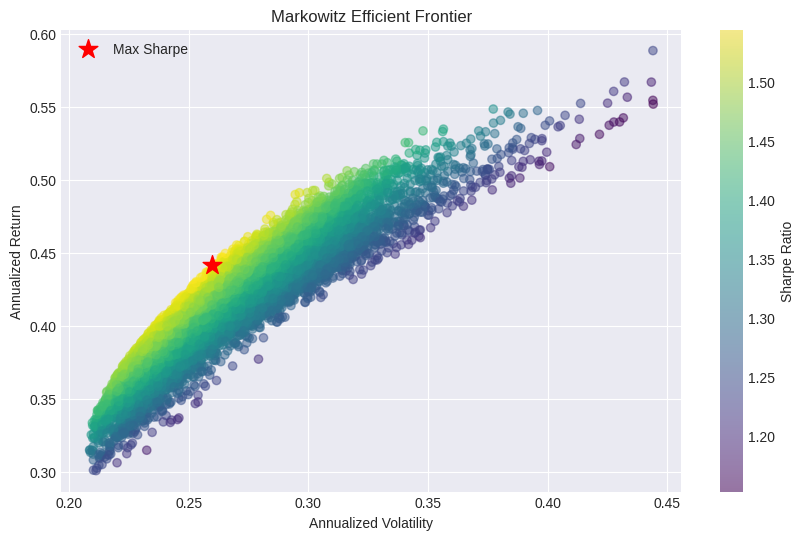

In [ ]:

num_portfolios = 10000
all_weights = np.zeros((num_portfolios, len(tickers)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights = weights / np.sum(weights)
    all_weights[i, :] = weights

    ret_arr[i] = np.sum(returns.mean() * weights) * 252
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    sharpe_arr[i] = (ret_arr[i] - risk_free_rate) / vol_arr[i]

max_sharpe_idx = sharpe_arr.argmax()
print("Optimal Weights for Maximum Sharpe Ratio Portfolio:")
for ticker, weight in zip(tickers, all_weights[max_sharpe_idx]):
    print(f"{ticker}: {weight:.4f}")


plt.figure(figsize=(10, 6))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', marker='o', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], color='red', marker='*', s=200, label='Max Sharpe')
plt.title('Markowitz Efficient Frontier')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.legend()
plt.show()

Markowitz Portfolio Optimization Interpretation

"The efficient frontier simulation shows the sweet spot where we maximize our portfolio's Sharpe ratio. The optimal weights tell us exactly how to split our capital across the tech stocks to get the highest possible return for the least amount of combined risk."

In [ ]:

headlines = [
    "Apple reports record-breaking quarterly revenue driven by strong iPhone sales.",
    "Supply chain bottlenecks pose severe challenges for tech hardware manufacturers.",
    "Federal Reserve hints at potential interest rate cuts amid slowing inflation.",
    "Amazon expands cloud computing infrastructure with massive new data center investments.",
    "Market analysts downgrade stock ratings following weaker-than-expected guidance."
]

sia = SentimentIntensityAnalyzer()
sentiment_results = []

for h in headlines:
    score = sia.polarity_scores(h)
    sentiment_results.append({'Headline': h, 'Compound Score': score['compound']})

df_sentiment = pd.DataFrame(sentiment_results)
print(df_sentiment)

                                            Headline  Compound Score
0  Apple reports record-breaking quarterly revenu...          0.5106
1  Supply chain bottlenecks pose severe challenge...         -0.3182
2  Federal Reserve hints at potential interest ra...          0.2023
3  Amazon expands cloud computing infrastructure ...          0.2732
4  Market analysts downgrade stock ratings follow...          0.0000


Financial Text Analytics Interpretation

"Running VADER sentiment analysis on the news headlines gives us a quick read on market mood. Positive announcements push the compound score closer to +1, while supply chain worries and weak guidance drag it down into negative territory, showing how external news can directly impact sentiment."